# 实验九：图像特征提取与几何变换

**实验目的：**
学习提取图像的高级几何特征（直线、圆、角点），为模式识别和计算机视觉打下基础。


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = images[i]
        if len(img.shape) == 3:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 1. 霍夫直线变换 (Hough Line Transform)

霍夫变换通过将图像空间中的点映射到参数空间（极坐标系下的 $\rho$ 和 $\theta$），把“寻找直线”的问题变成了“寻找参数空间中交点最多的峰值”的问题。
我们将使用**概率霍夫变换 (Probabilistic Hough Transform)**，它不仅能找到直线的方向，还能找到直线的起点和终点。


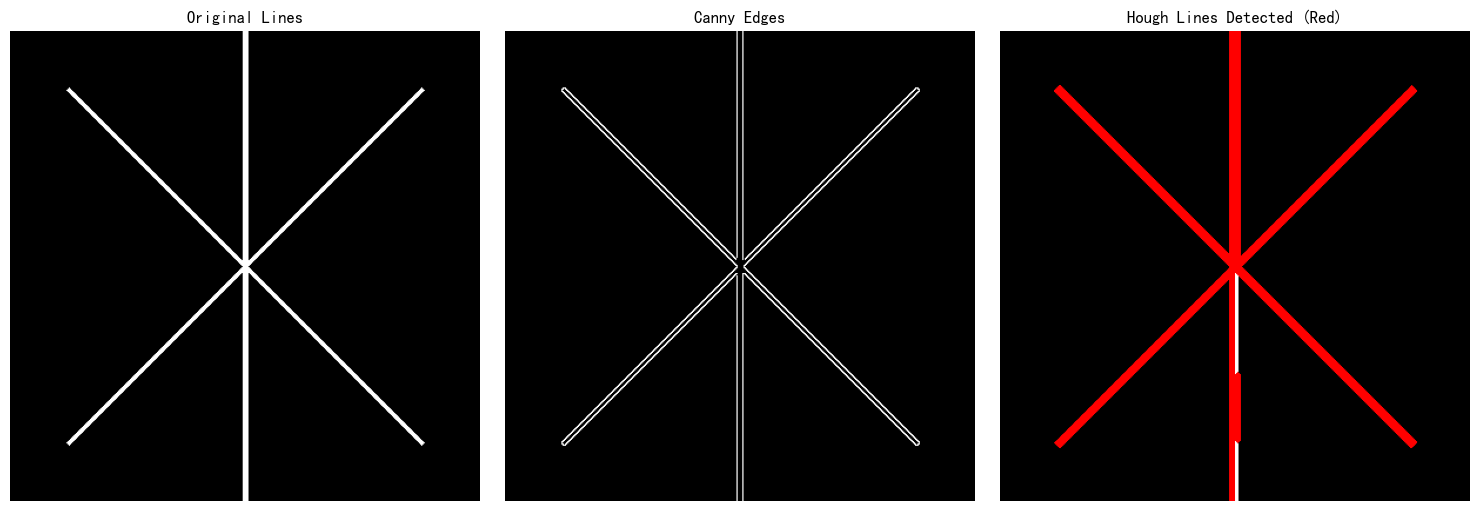

In [2]:
# 自动生成一张包含直线的测试图（模拟走廊或车道线）
img_lines = np.zeros((400, 400, 3), dtype=np.uint8)
cv2.line(img_lines, (50, 50), (350, 350), (255, 255, 255), 3)
cv2.line(img_lines, (50, 350), (350, 50), (255, 255, 255), 3)
cv2.line(img_lines, (200, 0), (200, 400), (255, 255, 255), 3)

# 转灰度并进行 Canny 边缘检测（霍夫变换的前提是提供边缘图）
gray_lines = cv2.cvtColor(img_lines, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray_lines, 50, 150)

# 概率霍夫变换
# 参数：边缘图，距离分辨率(像素)，角度分辨率(弧度)，阈值(交点数)，最短线段长度，最大断裂间隙
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=50, maxLineGap=10)

# 在原图上绘制检测到的直线（用红色标记）
img_lines_detected = img_lines.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines_detected, (x1, y1), (x2, y2), (0, 0, 255), 3)

show_images([img_lines, edges, img_lines_detected], 
            ["Original Lines", "Canny Edges", "Hough Lines Detected (Red)"])


## 2. 霍夫圆变换 (Hough Circle Transform)
类似于直线，霍夫圆变换可以用来检测图像中的圆形物体（如硬币、细胞、交通标志）。
OpenCV 中使用的是**霍夫梯度法**，它不需要提前进行 Canny 边缘检测，函数内部会自动处理。


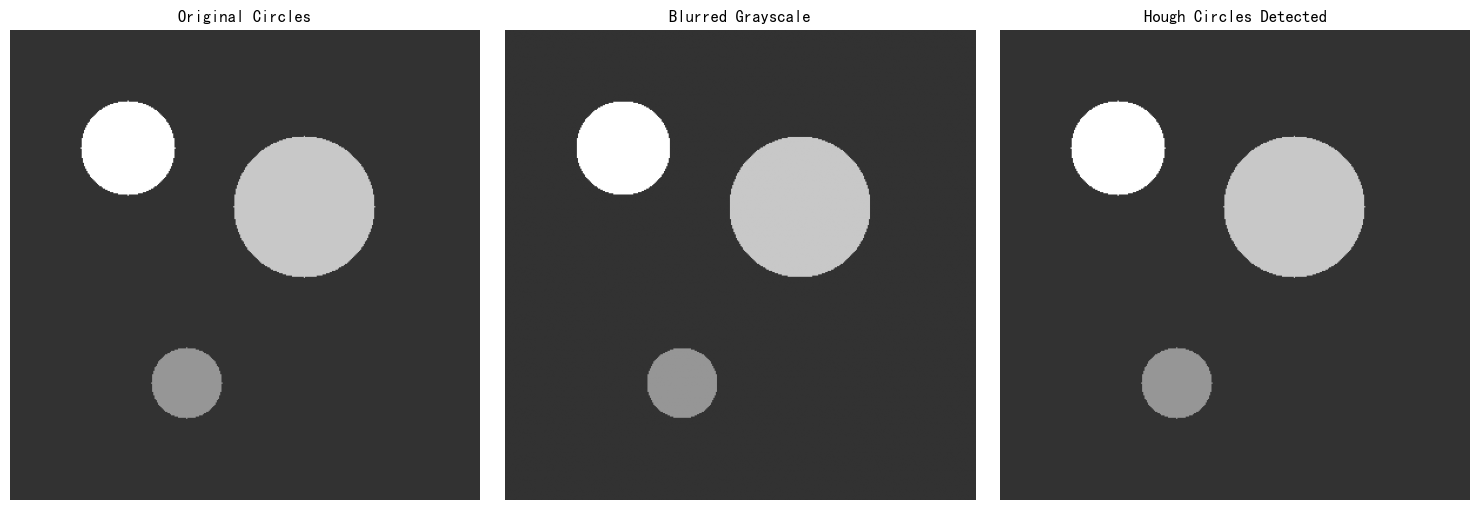

In [3]:
# 自动生成一张包含圆形的测试图（模拟硬币）
img_circles = np.full((400, 400, 3), 50, dtype=np.uint8)
cv2.circle(img_circles, (100, 100), 40, (255, 255, 255), -1)
cv2.circle(img_circles, (250, 150), 60, (200, 200, 200), -1)
cv2.circle(img_circles, (150, 300), 30, (150, 150, 150), -1)

gray_circles = cv2.cvtColor(img_circles, cv2.COLOR_BGR2GRAY)
# 为了减少误检测，通常先进行轻微的高斯模糊
gray_circles_blurred = cv2.medianBlur(gray_circles, 5)

# 霍夫圆变换
# 参数：灰度图，检测方法(梯度法)，分辨率倒数(1表示同分辨率)，圆心最小距离，Canny高阈值，累加器阈值，最小半径，最大半径
circles = cv2.HoughCircles(gray_circles_blurred, cv2.HOUGH_GRADIENT, 1, 
                           minDist=50, param1=100, param2=30, 
                           minRadius=20, maxRadius=100)

img_circles_detected = img_circles.copy()
if circles is not None:
    # 将坐标和半径转换为整数
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        # 绘制外圆 (绿色)
        cv2.circle(img_circles_detected, (i[0], i[1]), i[2], (0, 255, 0), 3)
        # 绘制圆心 (红色)
        cv2.circle(img_circles_detected, (i[0], i[1]), 2, (0, 0, 255), 3)

show_images([img_circles, gray_circles_blurred, img_circles_detected], 
            ["Original Circles", "Blurred Grayscale", "Hough Circles Detected"])


## 3. Harris 角点检测 (Harris Corner Detection)
角点是图像中**沿任何方向移动，局部灰度都会发生剧烈变化**的像素点。它是图像配准、全景拼接（Panorama）和 3D 重建中最稳健的特征点。


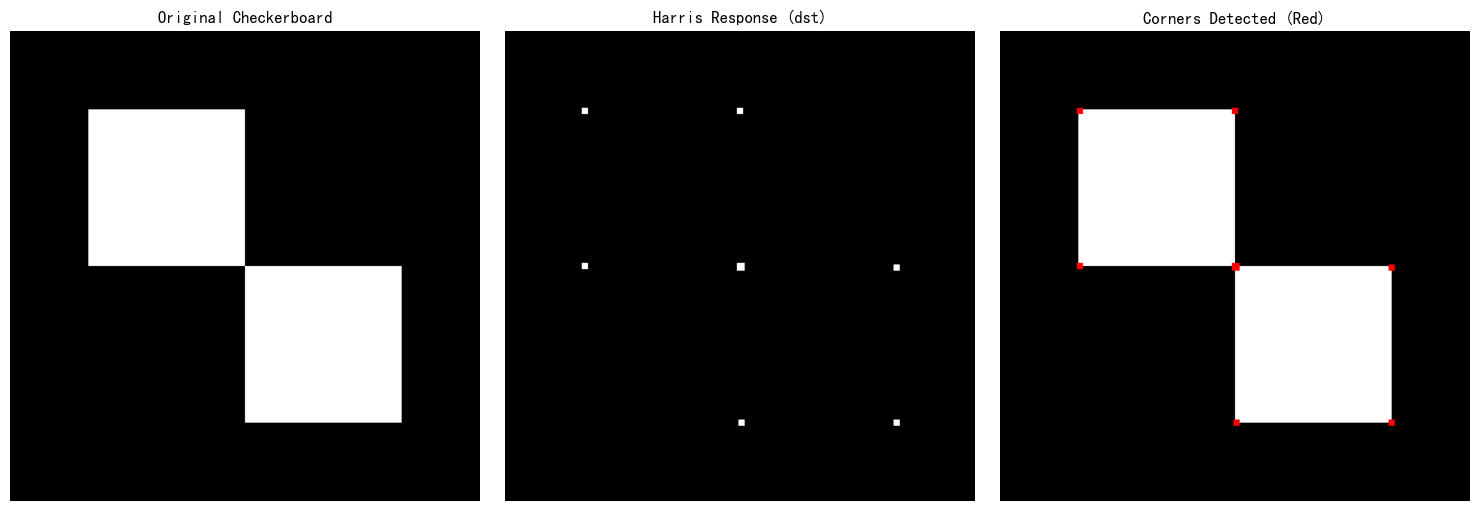

💡 结论：无论是直线、圆还是角点，数学模型都能在杂乱的像素矩阵中精准地找到我们需要的几何特征！


In [4]:
# 自动生成一张包含明显角点的测试图（棋盘格形）
img_corners = np.zeros((300, 300, 3), dtype=np.uint8)
img_corners[50:150, 50:150] = [255, 255, 255]
img_corners[150:250, 150:250] = [255, 255, 255]

gray_corners = cv2.cvtColor(img_corners, cv2.COLOR_BGR2GRAY)

# Harris 角点检测要求输入的数据类型必须为 float32
gray_corners_float = np.float32(gray_corners)

# 参数：灰度图，邻域大小(blockSize=2)，Sobel算子孔径大小(ksize=3)，Harris参数(k=0.04)
dst = cv2.cornerHarris(gray_corners_float, blockSize=2, ksize=3, k=0.04)

# 为了能清楚地在图像上看到角点，我们对检测结果进行一次形态学膨胀操作
dst = cv2.dilate(dst, None)

# 在原图上标记角点：当响应值大于最大响应值的 1% 时，我们认为它是一个角点，标记为红色
img_corners_detected = img_corners.copy()
img_corners_detected[dst > 0.01 * dst.max()] = [0, 0, 255]

show_images([img_corners, dst, img_corners_detected], 
            ["Original Checkerboard", "Harris Response (dst)", "Corners Detected (Red)"])

print("💡 结论：无论是直线、圆还是角点，数学模型都能在杂乱的像素矩阵中精准地找到我们需要的几何特征！")
